In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

Dataset Loaded Successfully
(3000, 15)
   UserID  TotalCourses  TotalSpent  AverageSpending        PreferredCategory  \
0  U00003            11      613.98        55.816364                Marketing   
1  U00004            13      982.05        75.542308        Digital Marketing   
2  U00013            14     1432.33       102.309286         Machine Learning   
3  U00015            14     2035.06       145.361429  Artificial Intelligence   
4  U00018            16     1468.03        91.751875  Artificial Intelligence   

  PreferredLevel  AverageCourseRating  DiversityScore  EnrollmentFrequency  \
0       Advanced             2.889091               7             1.571429   
1   Intermediate             3.451538               8             1.625000   
2       Advanced             2.869286               8             1.555556   
3       Beginner             2.760714              10             2.000000   
4       Beginner             3.108125               9             1.454545   

   Le

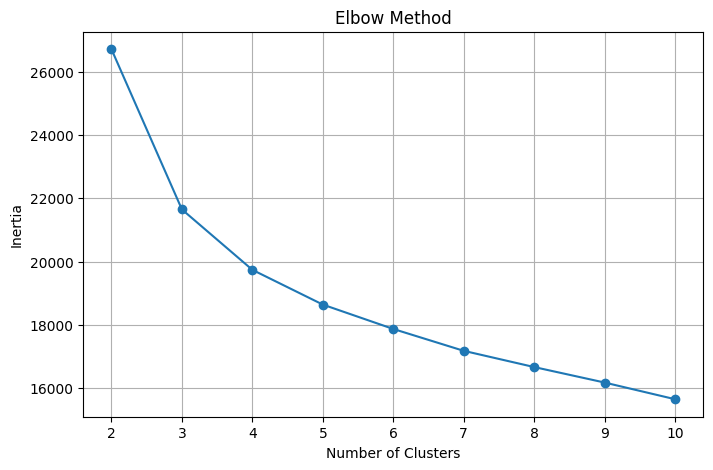


Silhouette Scores

K = 2  Score = 0.3967
K = 3  Score = 0.2773
K = 4  Score = 0.1881
K = 5  Score = 0.1779
K = 6  Score = 0.1648
K = 7  Score = 0.1585
K = 8  Score = 0.1485
K = 9  Score = 0.1234
K = 10  Score = 0.1584

Best K : 2
Best Score : 0.3967124891385535

KMeans Training Completed
Cluster
1    2540
0     460
Name: count, dtype: int64

Hierarchical Silhouette Score : 0.39446611582032515


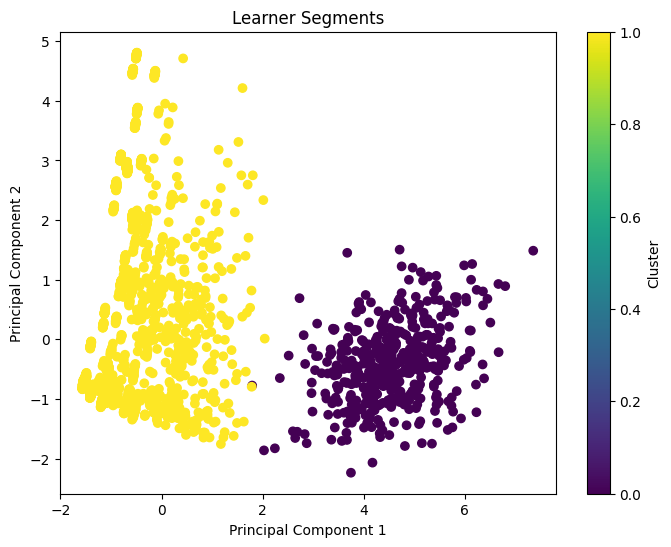

KMeans Model Saved
Clustered Dataset Saved


In [6]:
class LearnerSegmentation:

    def __init__(self):

        self.data = None

        self.processed_data = None

        self.scaler = StandardScaler()

        self.encoder = OneHotEncoder(handle_unknown="ignore")

        self.preprocessor = None

        self.kmeans = None

    ###########################################################
# LOAD DATA
###########################################################

    def load_data(self, file_path):

        self.data = pd.read_csv(file_path)

        print("Dataset Loaded Successfully")

        print(self.data.shape)

        print(self.data.head())

###########################################################
# REMOVE ID COLUMN
###########################################################

    def remove_id(self):
    
        # Save UserID before removing
        self.user_ids = self.data["UserID"].copy()
    
        self.data = self.data.drop(columns=["UserID"])

###########################################################
# HANDLE MISSING VALUES
###########################################################

    def handle_missing(self):

        numeric = self.data.select_dtypes(include=np.number).columns

        categorical = self.data.select_dtypes(include="object").columns

        for col in numeric:

            self.data[col] = self.data[col].fillna(
                self.data[col].median()
            )

        for col in categorical:

            self.data[col] = self.data[col].fillna(
                self.data[col].mode()[0]
            )

        print("Missing Values Handled")

###########################################################
# ENCODE + SCALE
###########################################################

    def preprocess(self):

        numeric_features = self.data.select_dtypes(
            include=np.number
        ).columns

        categorical_features = self.data.select_dtypes(
            include="object"
        ).columns

        self.preprocessor = ColumnTransformer(

            transformers=[

                (

                    "num",

                    StandardScaler(),

                    numeric_features

                ),

                (

                    "cat",

                    OneHotEncoder(handle_unknown="ignore"),

                    categorical_features

                )

            ]

        )

        self.processed_data = self.preprocessor.fit_transform(
            self.data
        )

        print("Preprocessing Complete")

        print(self.processed_data.shape)

###########################################################
# SAVE PREPROCESSOR
###########################################################

    def save_preprocessor(self):

        if not os.path.exists("models"):

            os.mkdir("models")

        joblib.dump(

            self.preprocessor,

            "models/preprocessor.pkl"

        )

        print("Preprocessor Saved")


###########################################################
# ELBOW METHOD
###########################################################

    def elbow_method(self):
    
        inertia = []
    
        K = range(2, 11)
    
        for k in K:
    
            model = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            )
    
            model.fit(self.processed_data)
    
            inertia.append(model.inertia_)

        plt.figure(figsize=(8,5))
    
        plt.plot(K, inertia, marker="o")
    
        plt.xlabel("Number of Clusters")
    
        plt.ylabel("Inertia")
    
        plt.title("Elbow Method")
    
        plt.grid(True)
    
        plt.show()

###########################################################
# SILHOUETTE SCORE
###########################################################

    def silhouette_analysis(self):
    
        best_score = -1
    
        best_k = 2
    
        print("\nSilhouette Scores\n")
    
        for k in range(2,11):
    
            model = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            )
    
            labels = model.fit_predict(self.processed_data)
    
            score = silhouette_score(
                self.processed_data,
                labels
            )

            print(f"K = {k}  Score = {score:.4f}")
    
            if score > best_score:
    
                best_score = score
    
                best_k = k

        print("\nBest K :", best_k)
    
        print("Best Score :", best_score)
    
        return best_k

###########################################################
# TRAIN KMEANS
###########################################################

    def train_kmeans(self, k):
    
        self.kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
    
        clusters = self.kmeans.fit_predict(
            self.processed_data
        )

        # Add UserID back
        self.data["UserID"] = self.user_ids.values
    
        # Add Cluster column
        self.data["Cluster"] = clusters
    
        print("\nKMeans Training Completed")
    
        print(self.data["Cluster"].value_counts())
    
        return clusters
###########################################################
# HIERARCHICAL CLUSTERING
###########################################################

    def hierarchical_validation(self, k):
    
        model = AgglomerativeClustering(
            n_clusters=k
        )
    
        labels = model.fit_predict(
            self.processed_data
        )
    
        score = silhouette_score(
            self.processed_data,
            labels
        )
    
        print("\nHierarchical Silhouette Score :", score)
    
        return labels

###########################################################
# PCA VISUALIZATION
###########################################################

    def visualize_clusters(self):
    
        pca = PCA(n_components=2)
    
        reduced = pca.fit_transform(
            self.processed_data
        )
    
        plt.figure(figsize=(8,6))
    
        plt.scatter(
    
            reduced[:,0],
    
            reduced[:,1],
    
            c=self.data["Cluster"],
    
            cmap="viridis"
    
        )

        plt.xlabel("Principal Component 1")
    
        plt.ylabel("Principal Component 2")
    
        plt.title("Learner Segments")
    
        plt.colorbar(label="Cluster")
    
        plt.show()
###########################################################
# SAVE DATA
###########################################################

    def save_dataset(self):
    
        self.data.to_csv(
    
            "clustered_learners.csv",
    
            index=False
    
        )
    
        print("Clustered Dataset Saved")
        
###########################################################
# SAVE MODEL
###########################################################

    def save_model(self):
    
        joblib.dump(
    
            self.kmeans,
    
            "models/kmeans.pkl"
    
        )
    
        print("KMeans Model Saved")
    
    ############################################################
# MAIN
############################################################

segment = LearnerSegmentation()

segment.load_data("learner_profiles.csv")

segment.remove_id()

segment.handle_missing()

segment.preprocess()

segment.save_preprocessor()

segment.elbow_method()

best_k = segment.silhouette_analysis()

segment.train_kmeans(best_k)

segment.hierarchical_validation(best_k)

segment.visualize_clusters()

segment.save_model()

segment.save_dataset()